<a href="https://colab.research.google.com/github/devdatta1429/BDA_Assignments/blob/main/PML/Day_23_11_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔰Random Forest🔰

In [1]:
from google.colab import drive
drive.mount('/content/drive')


import numpy as np
import pandas as pd

import os
os.chdir('/content/drive/MyDrive/CDAC/')

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

from numpy import random
from collections import Counter

from numpy.linalg import inv
from numpy.linalg import eig

import matplotlib
from matplotlib import pyplot as plt

import seaborn as sns

import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split

import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from scipy.stats import chisquare
from scipy.stats import chi2_contingency

from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

from scipy.stats import f
from sklearn.metrics import mean_squared_error

from sklearn.metrics import roc_auc_score

#========================================================================

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.discrete.discrete_model import MNLogit

import sklearn
from sklearn.model_selection import train_test_split



import pandas as pd
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# from category_encoders import BinaryEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#   this will give the area of the left side we want the area of the right side so we do the 1 -
1 - binom.cdf(7,15,0.7)

np.float64(0.9499874599462239)

In [3]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'diabetes')
df = df[['Glucose','BloodPressure','Age','DietType','Outcome']]

diet_dummy = pd.get_dummies(df.DietType, drop_first=True, prefix='Diet').astype(int)
df = df.drop('DietType', axis=1)
df = pd.concat([df,diet_dummy], axis=1)

x= df.drop('Outcome', axis=1)  # column of predictors
y= df.Outcome   # column of response

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)

y_pred=dtc.predict(x_test)
from sklearn.metrics import confusion_matrix,classification_report

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

# hyperparameter tuning

param={
    'criterion':['gini','entropy', 'log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7],
    'max_features':['auto','sqrt','log2'],
    'min_samples_split' : [2,3,4,5],
    'min_samples_leaf' : [2,3,4,5]
}

from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(dtc,param_grid=param,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_

dtc = DecisionTreeClassifier(criterion= 'gini',
 max_depth= 5,
 max_features= 'sqrt',
 min_samples_leaf= 5,
 min_samples_split= 2,
 splitter= 'best')

dtc.fit(x_train,y_train)
print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

y_pred = dtc.predict(x_test)
print(confusion_matrix(y_test,y_pred))

[[86 15]
 [15 38]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       101
           1       0.72      0.72      0.72        53

    accuracy                           0.81       154
   macro avg       0.78      0.78      0.78       154
weighted avg       0.81      0.81      0.81       154

1.0
0.8051948051948052
0.8615635179153095
0.8181818181818182
[[86 15]
 [13 40]]


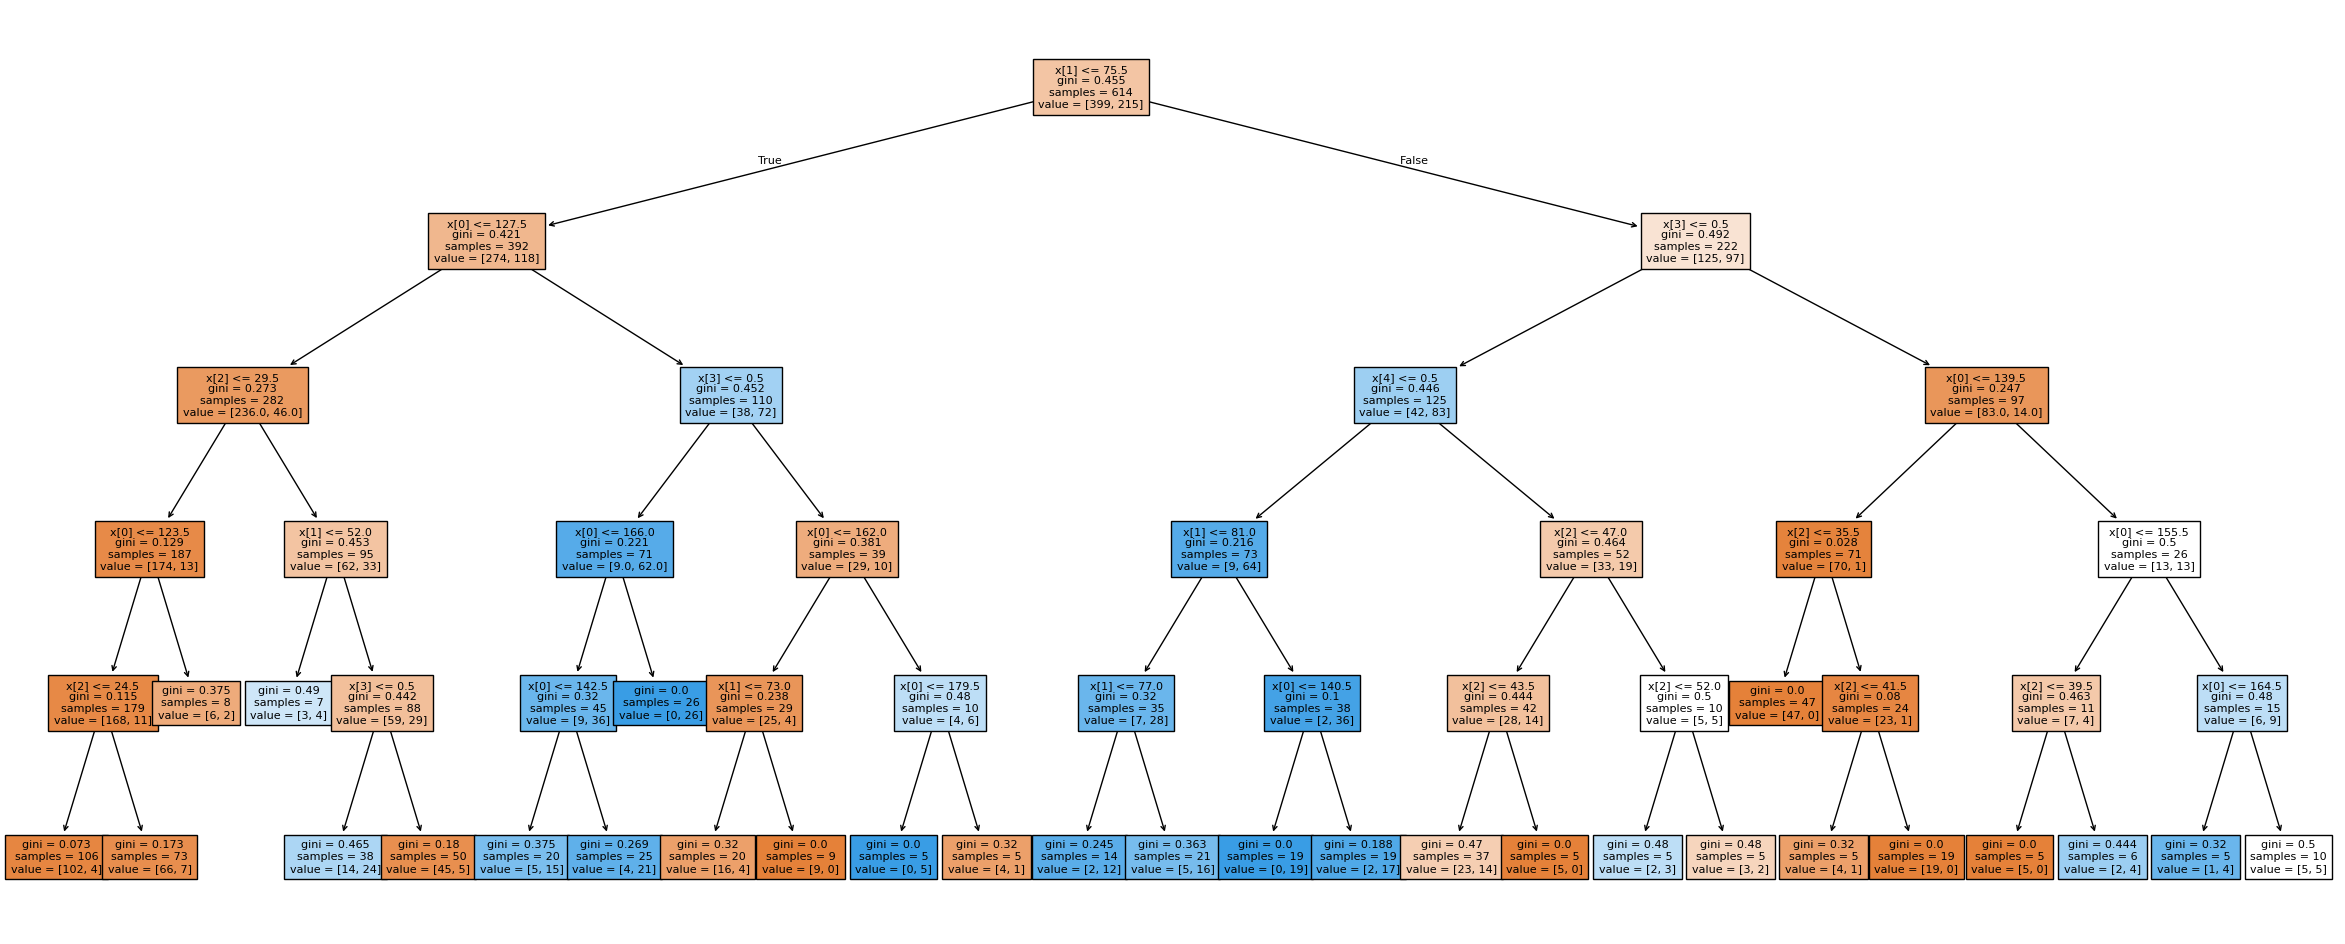

In [4]:
plt.figure(figsize=(30, 12))
tree.plot_tree( dtc,filled=True,fontsize=8 )  # increase text size
plt.show()

# 🔰Random Forest(N* Decision Tree)🔰

- #### the random forest would be the group of the x number of decision trees
- #### the decision in random forest are taken by the rule of majority
#### in categorical rule of majority(mode)
#### continuous the average will taken.
- #### the random forest will have all the hyperparameter of decision tree plus one more n_estimators.
---
#### The decision tree are less prone to outliers.

- the first the decision tree in series of the boosting model called as weak learner.
- the last the decision tree in series of the boosting model called as strong learner.(because that model is elarn from the mistakes)

FOR FEATURE SELECTION WE WILL USE:

- LASSO

- MULTICOLLINARITY(VIF)

- COEFFICIENT OF VARIATION

- P VALUE USING INFERENTIAL TOOLS

- IF VARIATION IS LESS IN DATA

- EMPIRICAL TOOL: INFO GAIN

FIRST DECISION TREE IN THE SERIES OF BOOSTING MODEL IS CALLED WEAK LEARNER.

LAST DECISION TREE IS CALLED STRONG BOOSTING MODEL


---
| P1 (PREDICTION) | A (ACTUAL) | E (ERROR) | 0.1 * E (LEARNING RATE * ERROR) | P2 (NEW PRED) |
| :---: | :---: | :---: | :---: | :---: |
| 8 | 9.3 | 1.3 | 0.13 | 8.13 |
---

IF WE MAKE BIG ADJUSTMENT TO PREDICTION WE WILL LOST POINT OF MINIMA WHICH HAS LESS DIFF B/W PRED AND ACTUAL


P=P+0.1NLV

NLV=AVG RESIDUAL/HESSIAN(VARIANCE)

WHEN AND WHY NLV BIGGER:

The NLV is a ratio of how far we are from the point of minima to the variance

- if residual is high and variance is low than the value of NLV is high
 so bigger change can be made in original logic

- if residual is low and variance is high than the value of NLV is low
 so lesser change can be made in original logic


- new weight are calculated in such a way by ensuring that the rows where the error is high should get high weights

# Gradient Boosting (Regression)

### Step 1: Build the Base Model

* Calculate the average of the target variable.
* This average value becomes the initial prediction for all rows.

$$
\hat{y}_0 = \frac{\sum y_i}{N}
$$

---

### Step 2: Calculate Residuals

* Compute the residual (error) for each row.

$$
Residual = Actual - Prediction
$$

* Residuals represent the information that the current model has failed to learn.

---

### Step 3: Train the First Decision Tree

* Fit a decision tree on the residuals instead of the original target variable.
* The tree learns the patterns present in the errors.

---

### Step 4: Make Residual Predictions

* Use the decision tree to predict the residuals for each observation.
* These predicted residuals indicate how much the current prediction should be corrected.

---

### Step 5: Update Predictions

* Add the predicted residuals to the previous predictions.

$$
New\ Prediction =
Old\ Prediction + Learning\ Rate \times Predicted\ Residual
$$

* The learning rate controls how much correction is applied at each step.

---

### Step 6: Calculate New Residuals

* Compute the new residuals using the updated predictions.

$$
Residual = Actual - New\ Prediction
$$

* The errors should now be smaller than before.

---

### Step 7: Build the Next Tree

* Train another decision tree on the new residuals.
* This tree focuses on the mistakes that the previous trees could not correct.

---

### Step 8: Repeat the Process

* Continue building trees sequentially.
* Each new tree learns from the residuals of the previous model.

---

### Final Prediction

$$
Final\ Prediction =
Base\ Prediction
+
\eta T_1
+
\eta T_2
+
\eta T_3
+\cdots+
\eta T_n
$$

Where:

* (\eta) = Learning Rate
* (T_1, T_2, ..., T_n) = Predictions from individual trees

---

## Key Idea

* AdaBoost increases the weight of incorrectly predicted observations.
* Gradient Boosting fits a new tree on the residuals (errors) of the previous model.
* Each tree tries to reduce the remaining error left by the earlier trees.
* Trees are added sequentially until the residuals become very small.


## 🔰GB - Attribute🔰

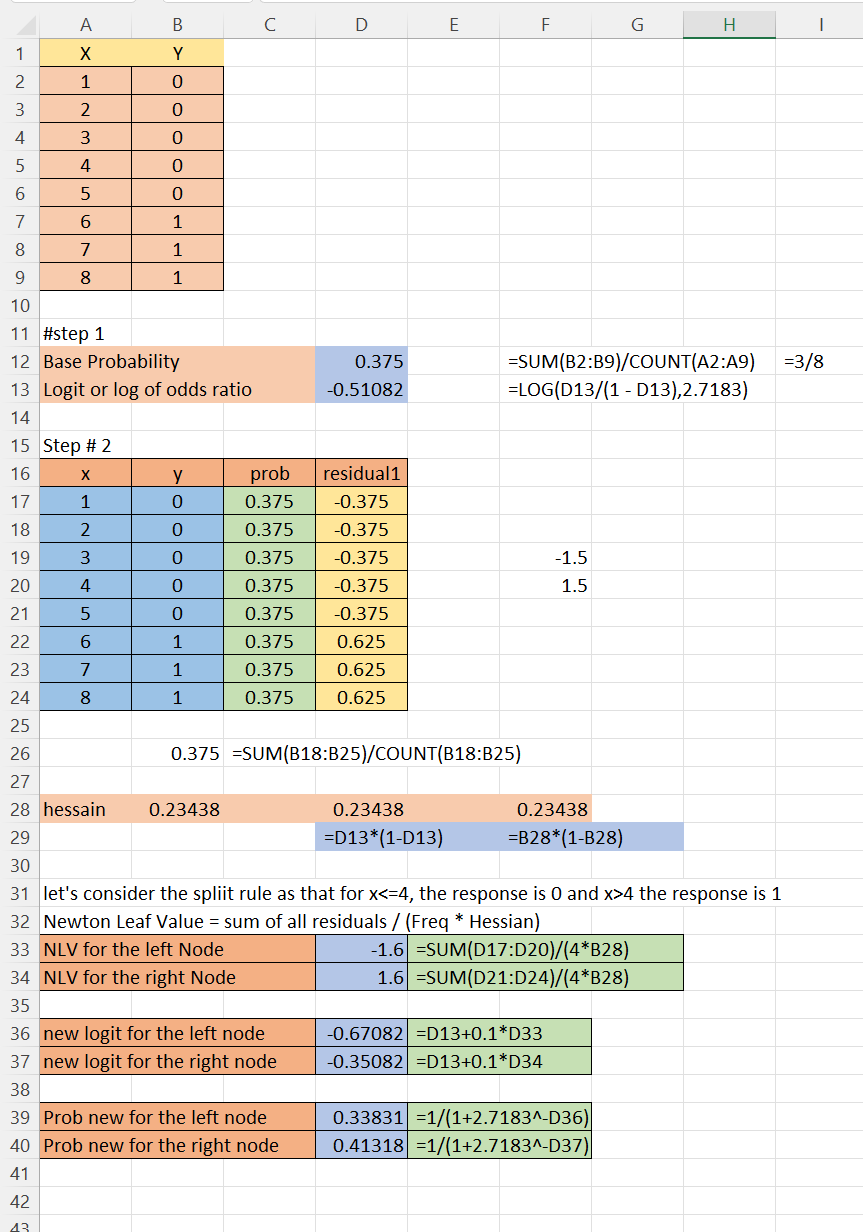

$$
\text{NLV} = \frac{\text{Avg Residual} \uparrow}{\text{Hessian (Variance)} \downarrow}
$$
#
$$
\text{NLV} = \frac{\text{Avg Residual} \downarrow}{\text{Hessian (Variance)} \uparrow}
$$


- NLV is formulae of how far we are from the minima to the varience.
- if the residual is the more and varience is the low then value of NLV is high,\
and the bigger change can be made  in original logic

#

- if the residual is the low and varience is the high then value of NLV is low value,\
and the bigger change can be made in original logic

## 🔰GB - Continuous🔰

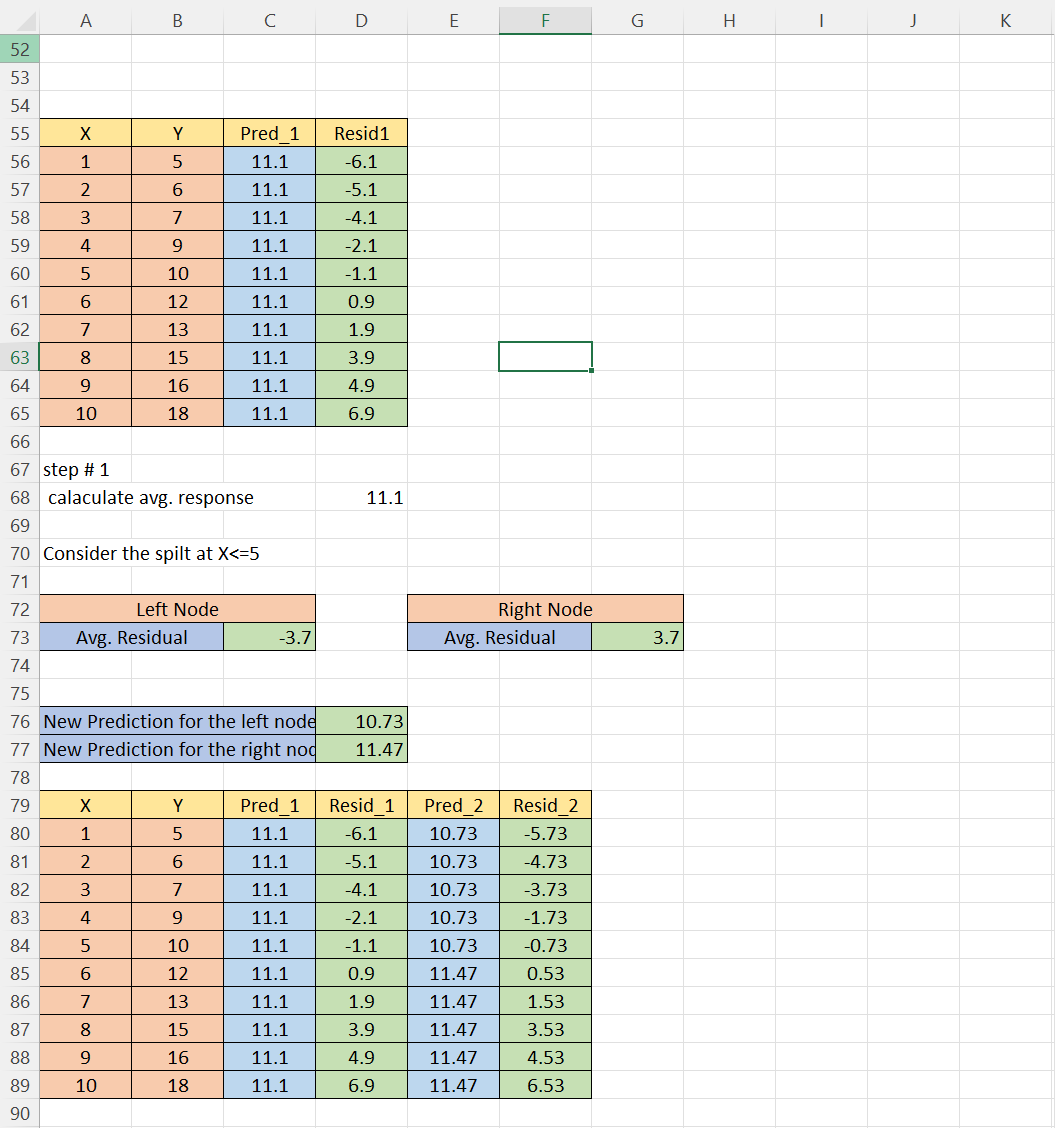

# AdaBoost (Continuous Data)

### Step 1

* Equal weights are assigned to all rows initially.
* Base predictions are made using the average value of the target variable.

### Step 2

* Calculate the residual (error) for each row.
* Update the weights based on the residuals.
* Rows with higher residuals receive higher weights, while rows with lower residuals receive lower weights.

### Step 3

* The updated weights determine how frequently each row will be selected for the next decision tree.
* Rows with higher weights have a greater chance of appearing multiple times in the next training sample.

### Step 4

* During the construction of the next decision tree, rows with larger residuals (higher weights) appear more often than rows with smaller residuals (lower weights).
* As a result, the model focuses more on observations with larger prediction errors.

### Note

* For continuous data, regions containing larger errors tend to receive more attention from subsequent trees.
* This often results in larger bins/partitions being created to better capture and reduce those errors.


In [5]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'diabetes')
df = df[['Glucose','BloodPressure','Age','DietType','Outcome']]

diet_dummy = pd.get_dummies(df.DietType, drop_first=True, prefix='Diet').astype(int)
df = df.drop('DietType', axis=1)
df = pd.concat([df,diet_dummy], axis=1)

x= df.drop('Outcome', axis=1)  # column of predictors
y= df.Outcome   # column of response

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)

y_pred=dtc.predict(x_test)
from sklearn.metrics import confusion_matrix,classification_report

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

# hyperparameter tuning

param={
    'criterion':['gini','entropy', 'log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7],
    'max_features':['auto','sqrt','log2'],
    'min_samples_split' : [2,3,4,5],
    'min_samples_leaf' : [2,3,4,5]
}

from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(dtc,param_grid=param,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_

dtc = DecisionTreeClassifier(criterion= 'gini',
 max_depth= 5,
 max_features= 'sqrt',
 min_samples_leaf= 5,
 min_samples_split= 2,
 splitter= 'best')

dtc.fit(x_train,y_train)
print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

y_pred = dtc.predict(x_test)
print(confusion_matrix(y_test,y_pred))

[[82 19]
 [16 37]]
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       101
           1       0.66      0.70      0.68        53

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.78      0.77      0.77       154

1.0
0.7727272727272727
0.8908794788273615
0.8766233766233766
[[97  4]
 [15 38]]
